# TsUtils — 函数参数、返回对象与调用示例

## Goal

本 notebook 是 `TsUtils` 六个公共功能的可执行使用手册。每一节都回答五个问题：

1. 函数解决什么问题；
2. 每个参数是什么意思；
3. 函数返回什么类型；
4. 返回对象有哪些字段、属性和方法；
5. 如何调用、查看和继续使用结果。

所有数据均在本地确定性生成，不依赖外部文件。建议按顺序从头运行。

## 快速选择

| 需求 | 接口 | 返回值 |
|---|---|---|
| 普通、对数、季节或高阶差分 | `difference()` | `Series` 或 `DataFrame` |
| Box-Cox 幂变换 | `boxcox()` | `BoxCoxResult` |
| 缺失值插值并记录填补情况 | `interpolate_missing()` | `InterpolationResult` |
| 描述统计与 ACF/PACF | `TimeSeriesSummary` | 分析对象本身；`summary()` 返回文本，`plot()` 返回图形 |
| 非季节 ARMA 阶数识别 | `eacf()` | `EACFResult` |
| STL 趋势—季节分解 | `STL(...).fit()` | `STLResult` |

## Setup

导入全部公共接口并构造两条严格为正的月度时间序列。后续示例会复用这些数据。

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display

# 支持从仓库根目录或 TsUtils 目录直接执行本 notebook。
working_directory = Path.cwd().resolve()
package_directory = next(
    (
        candidate
        for candidate in (working_directory, *working_directory.parents)
        if candidate.name == "Ts" and (candidate / "TsUtils").is_dir()
    ),
    None,
)
if package_directory is not None:
    sys.path.insert(0, str(package_directory.parent))

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
plot_font = next(
    (
        name
        for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC")
        if name in available_fonts
    ),
    "DejaVu Sans",
)
plt.rcParams["font.sans-serif"] = [plot_font]
plt.rcParams["axes.unicode_minus"] = False

from Ts.TsUtils import (
    BoxCoxResult,
    EACFResult,
    InterpolationResult,
    STL,
    STLResult,
    TimeSeriesSummary,
    boxcox,
    difference,
    eacf,
    interpolate_missing,
)

rng = np.random.default_rng(20260801)
index = pd.date_range("2015-01-01", periods=120, freq="MS")
time = np.arange(len(index))

complete_series = pd.Series(
    100
    + 0.25 * time
    + 8 * np.sin(2 * np.pi * time / 12)
    + rng.normal(scale=1.2, size=len(index)),
    index=index,
    name="sales",
)
transactions = pd.Series(
    40
    + 0.12 * time
    + 4 * np.cos(2 * np.pi * time / 12)
    + rng.normal(scale=0.8, size=len(index)),
    index=index,
    name="transactions",
)
data_frame = pd.concat([complete_series, transactions], axis=1)
display(data_frame.head())

,sales,transactions
2015-01-01,99.200680,43.609055
2015-02-01,102.073326,43.044950
2015-03-01,105.842219,43.183847
2015-04-01,106.820540,40.610781
2015-05-01,109.218311,37.114362


## 1. `difference()`：差分变换

### 函数签名

```python
difference(data, *, order=1, log=False, lag=1)
```

### 参数

| 参数 | 类型与默认值 | 含义 |
|---|---|---|
| `data` | `Series` 或 `DataFrame` | 数值时间序列。DataFrame 按列独立计算；保留索引、名称、列名和长度。 |
| `order` | `1` 或 `2`，默认 `1` | 差分次数。`2` 表示对第一次差分结果再次应用同一 `lag`。 |
| `log` | `bool`，默认 `False` | 是否先取自然对数再差分。设为 `True` 时，全部非缺失值必须严格大于零。 |
| `lag` | 正整数，默认 `1` | 按观测位置计算的间隔。月度同比用 `12`，季度同比用 `4`。不会根据日期自动猜测。 |

一阶差分为 `(1-L^lag)x_t`；二阶差分为 `(1-L^lag)^2 x_t`。输入必须是实数、非布尔的 pandas 对象；拒绝无穷值和重复的 DataFrame 列名。

### 返回值

直接返回新的浮点型 `Series` 或 `DataFrame`，不是结果包装对象。差分产生的前置缺失值和输入缺失值均保留。

In [2]:
first_difference = difference(complete_series)
second_difference = difference(complete_series, order=2)
first_log_difference = difference(complete_series, log=True)
monthly_yoy_log_difference = difference(
    complete_series,
    log=True,
    lag=12,
)

difference_examples = pd.DataFrame(
    {
        "level": complete_series,
        "first": first_difference,
        "second": second_difference,
        "log_first": first_log_difference,
        "monthly_yoy_log": monthly_yoy_log_difference,
    }
)
display(difference_examples.head(15))

,level,first,second,log_first,monthly_yoy_log
2015-01-01,99.200680,NaN,NaN,NaN,NaN
2015-02-01,102.073326,2.872647,NaN,0.028547,NaN
2015-03-01,105.842219,3.768892,0.896246,0.036258,NaN
2015-04-01,106.820540,0.978322,-2.790571,0.009201,NaN
2015-05-01,109.218311,2.397770,1.419449,0.022198,NaN
2015-06-01,104.313036,-4.905274,-7.303045,-0.045952,NaN
2015-07-01,99.844026,-4.469010,0.436264,-0.043787,NaN
2015-08-01,97.320910,-2.523116,1.945894,-0.025595,NaN
2015-09-01,94.946331,-2.374579,0.148537,-0.024702,NaN
2015-10-01,94.452271,-0.494060,1.880519,-0.005217,NaN


### 如何查看返回结果

因为返回值就是 pandas 对象，可以直接使用 `.head()`、`.tail()`、`.isna()`、`.plot()` 等 pandas 方法。调用不会修改原数据。

In [3]:
difference_info = pd.Series(
    {
        "return_type": type(first_difference).__name__,
        "series_name": first_difference.name,
        "same_index": first_difference.index.equals(complete_series.index),
        "same_length": len(first_difference) == len(complete_series),
        "first_difference_missing": int(first_difference.isna().sum()),
        "monthly_yoy_missing": int(monthly_yoy_log_difference.isna().sum()),
    },
    name="difference result",
)
display(difference_info)

return_type                 Series
series_name                  sales
same_index                    True
same_length                   True
first_difference_missing         1
monthly_yoy_missing             12
Name: difference result, dtype: object

## 2. `boxcox()`：Box-Cox 幂变换

### 函数签名

```python
boxcox(data, *, lmbda=None)
```

### 参数

| 参数 | 类型与默认值 | 含义 |
|---|---|---|
| `data` | `Series` 或 `DataFrame` | 严格正的实数数据。允许缺失值并保留其位置；拒绝零、负值和无穷值。 |
| `lmbda` | `None`、有限实数、映射或 `Series` | `None` 表示最大似然估计 λ。Series 只能使用一个标量 λ；DataFrame 可用一个标量作用于全部列，或按列名提供 λ。 |

`lmbda=0` 等价于自然对数变换。函数不会自动给非正数据添加平移常数。自动估计时，每条序列至少需要两个非缺失且不完全相同的观测。

### 返回值：`BoxCoxResult`

| 字段 | 类型 | 如何使用 |
|---|---|---|
| `.data` | `Series` 或 `DataFrame` | 取得转换后的数据。 |
| `.lmbda` | `float` 或 `Series` | Series 返回一个 λ；DataFrame 返回按列索引的 λ Series。 |

预测场景中应只在训练集估计 λ，再将其传给验证集或未来数据，避免未来信息泄漏。

In [4]:
training_size = 96
boxcox_training = complete_series.iloc[:training_size]
boxcox_holdout = complete_series.iloc[training_size:]

# lmbda=None：在训练集自动估计 λ。
boxcox_fitted = boxcox(boxcox_training)

# 显式传入训练集 λ：对留出集只做变换，不重新估计。
boxcox_applied = boxcox(
    boxcox_holdout,
    lmbda=boxcox_fitted.lmbda,
)
boxcox_transformed = pd.concat(
    [boxcox_fitted.data, boxcox_applied.data]
)

print(f"返回类型：{type(boxcox_fitted).__name__}")
print(f"训练集估计的 lambda：{boxcox_fitted.lmbda:.6f}")

返回类型：BoxCoxResult
训练集估计的 lambda：0.983616


In [5]:
# 通过 .data 取得转换值，通过 .lmbda 取得参数。
boxcox_boundary = pd.DataFrame(
    {
        "level": complete_series,
        "boxcox": boxcox_transformed,
    }
).iloc[92:100]
display(boxcox_boundary)

,level,boxcox
2022-09-01,114.097450,106.318790
2022-10-01,115.735312,107.834160
2022-11-01,115.896345,107.983131
2022-12-01,119.023246,110.875145
2023-01-01,124.895669,116.303102
2023-02-01,130.534118,121.510858
2023-03-01,132.020293,122.882891
2023-04-01,131.330748,122.246336


### DataFrame：自动逐列估计、复用和显式逐列设置

- `lmbda=None`：每列独立估计 λ；
- `lmbda=0.5`：全部列使用同一个 λ；
- `lmbda={"sales": 0.0, "transactions": 0.5}`：按列指定。

In [6]:
boxcox_frame_fitted = boxcox(data_frame.iloc[:training_size])
boxcox_frame_applied = boxcox(
    data_frame.iloc[training_size:],
    lmbda=boxcox_frame_fitted.lmbda,
)
boxcox_frame_custom = boxcox(
    data_frame.head(),
    lmbda={"sales": 0.0, "transactions": 0.5},
)

lambda_comparison = pd.DataFrame(
    {
        "estimated_on_training": boxcox_frame_fitted.lmbda,
        "reused_on_holdout": boxcox_frame_applied.lmbda,
        "custom": boxcox_frame_custom.lmbda,
    }
)
display(lambda_comparison)
display(boxcox_frame_custom.data.head())

,estimated_on_training,reused_on_holdout,custom
sales,0.983616,0.983616,0.0
transactions,1.155955,1.155955,0.5


,sales,transactions
2015-01-01,4.597145,11.207430
2015-02-01,4.625691,11.121730
2015-03-01,4.661949,11.142883
2015-04-01,4.671150,10.745318
2015-05-01,4.693349,10.184312


## 3. `interpolate_missing()`：缺失值插值与审计

### 函数签名

```python
interpolate_missing(data, method="linear", *, max_gap=None, edge="keep")
```

### 参数

| 参数 | 类型与默认值 | 含义 |
|---|---|---|
| `data` | 一维/二维数组、`Series` 或 `DataFrame` | 按行排序的数值观测；二维数据按列独立插值。 |
| `method` | 默认 `"linear"` | 插值算法，见下表。 |
| `max_gap` | `None` 或正整数 | 允许填补的最大连续缺失长度；超过限制的缺口整段保留。`None` 表示不限制长度。 |
| `edge` | `"keep"` 或 `"nearest"` | `keep` 只填内部缺口；`nearest` 允许用最近观测延伸填补首尾缺口。 |

| `method` | 含义与约束 |
|---|---|
| `"linear"` | 按观测位置线性插值。 |
| `"time"` | 按真实时间间隔插值；要求唯一、递增的 `DatetimeIndex` 或 `TimedeltaIndex`。 |
| `"nearest"` | 最近邻插值；依赖 SciPy。 |
| `"cubic"` | 三次插值；依赖 SciPy，且需要足够有效观测。 |

### 返回值：`InterpolationResult`

| 字段、属性或方法 | 含义 |
|---|---|
| `.data` | 插值后的数据，保持原容器类型和标签。 |
| `.missing_mask` | 原始缺失位置的布尔数组。 |
| `.filled_mask` | 本次成功填补位置的布尔数组。 |
| `.remaining_mask` | 原始缺失但仍未填补的位置。 |
| `.method`、`.max_gap`、`.edge` | 实际使用的配置。 |
| `.n_missing`、`.n_filled`、`.n_remaining` | 原缺失、已填补和剩余缺失的数量。 |
| `.complete` | 是否已填补全部原始缺失值。 |
| `.summary()` | 返回审计摘要文本。 |

In [7]:
series_with_gap = complete_series.copy()
series_with_gap.iloc[24:26] = np.nan

interpolation = interpolate_missing(
    series_with_gap,
    method="linear",
    max_gap=2,
    edge="keep",
)

interpolation_view = pd.DataFrame(
    {
        "original": series_with_gap,
        "interpolated": interpolation.data,
        "was_missing": interpolation.missing_mask,
        "was_filled": interpolation.filled_mask,
        "still_missing": interpolation.remaining_mask,
    }
).iloc[21:29]
display(interpolation_view)

,original,interpolated,was_missing,was_filled,still_missing
2016-10-01,97.358117,97.358117,False,False,False
2016-11-01,96.851839,96.851839,False,False,False
2016-12-01,101.654053,101.654053,False,False,False
2017-01-01,NaN,105.864765,True,True,False
2017-02-01,NaN,110.075476,True,True,False
2017-03-01,114.286188,114.286188,False,False,False
2017-04-01,115.759446,115.759446,False,False,False
2017-05-01,113.196755,113.196755,False,False,False


In [8]:
print(interpolation.summary())
interpolation_attributes = pd.Series(
    {
        "return_type": type(interpolation).__name__,
        "method": interpolation.method,
        "max_gap": interpolation.max_gap,
        "edge": interpolation.edge,
        "n_missing": interpolation.n_missing,
        "n_filled": interpolation.n_filled,
        "n_remaining": interpolation.n_remaining,
        "complete": interpolation.complete,
    },
    name="InterpolationResult",
)
display(interpolation_attributes)

Interpolation Result
Method          : linear
Maximum gap     : 2
Edge policy     : keep
Missing values  : 2
Filled values   : 2
Remaining       : 0
Complete        : True


return_type    InterpolationResult
method                      linear
max_gap                          2
edge                          keep
n_missing                        2
n_filled                         2
n_remaining                      0
complete                      True
Name: InterpolationResult, dtype: object

### `max_gap` 和 `edge` 的行为

下面同时展示：长于 `max_gap` 的内部缺口保持不变，以及 `edge="nearest"` 对首尾缺口的显式填补。

In [9]:
long_gap_series = complete_series.iloc[:12].copy()
long_gap_series.iloc[3:7] = np.nan
long_gap_result = interpolate_missing(
    long_gap_series,
    max_gap=2,
)

edge_series = pd.Series(
    [np.nan, 2.0, 4.0, np.nan],
    name="edge_example",
)
edge_result = interpolate_missing(
    edge_series,
    max_gap=1,
    edge="nearest",
)

display(
    pd.DataFrame(
        {
            "long_gap_original": long_gap_series,
            "long_gap_result": long_gap_result.data,
        }
    )
)
display(pd.DataFrame({"edge_original": edge_series, "edge_result": edge_result.data}))

,long_gap_original,long_gap_result
2015-01-01,99.200680,99.200680
2015-02-01,102.073326,102.073326
2015-03-01,105.842219,105.842219
2015-04-01,NaN,NaN
2015-05-01,NaN,NaN
2015-06-01,NaN,NaN
2015-07-01,NaN,NaN
2015-08-01,97.320910,97.320910
2015-09-01,94.946331,94.946331
2015-10-01,94.452271,94.452271


,edge_original,edge_result
0,NaN,2.0
1,2.0,2.0
2,4.0,4.0
3,NaN,4.0


## 4. `TimeSeriesSummary`：描述统计与 ACF/PACF

### 构造签名

```python
TimeSeriesSummary(data, variable=None, *, nlags=None, alpha=0.05)
```

### 参数

| 参数 | 类型与默认值 | 含义 |
|---|---|---|
| `data` | 一维数组、`Series` 或 `DataFrame` | 要分析的一条数值序列。多列 DataFrame 必须显式指定 `variable`。 |
| `variable` | 列名或 `None` | 选择 DataFrame 中唯一的一列；对 Series 传入该参数会报错。 |
| `nlags` | `None` 或正整数 | ACF/PACF 最大滞后阶数。`None` 会在样本允许范围内取不超过 40 的值。 |
| `alpha` | `(0, 1)` 内浮点数，默认 `0.05` | ACF/PACF 置信区间显著性水平。 |

### 返回对象及访问方式

构造函数返回 `TimeSeriesSummary` 分析对象。

| 属性或方法 | 含义 |
|---|---|
| `.series` | 实际选中的独立 Series 副本。 |
| `.nlags`、`.alpha` | 实际保存的滞后阶数设置和显著性水平。 |
| `.nobs` | 总观测数，包含缺失值。 |
| `.n_missing`、`.missing_ratio`、`.missing_timestamps` | 缺失信息。 |
| `.frequency` | 明确、推断出的频率，或不可识别提示。 |
| `.summary(plot=True)` | 返回描述统计文本；默认还会生成诊断图。只要文本时使用 `plot=False`。 |
| `.plot()` | 返回 `(figure, axes)`，绘制水平值和一阶差分的 ACF/PACF。 |
| `.figure_`、`.axes_` | 绘图后保存的 Matplotlib 对象。 |

若序列含缺失值，摘要仍会生成，但不会静默删除或插值来计算 ACF/PACF。

In [10]:
# 多列 DataFrame 必须用 variable 指定要分析的列。
summary_analysis = TimeSeriesSummary(
    data_frame,
    variable="sales",
    nlags=18,
    alpha=0.05,
)

# plot=False：只返回文本，不自动绘图。
print(summary_analysis.summary(plot=False))

Time Series Summary
Name               : sales
Observations       : 120
Valid observations : 120
Frequency          : MS
Start              : 2015-01-01T00:00:00
End                : 2024-12-01T00:00:00
Missing values     : 0
Missing ratio      : 0.00%
Missing timestamps : None
--------------------------------------------------
Mean               : 114.646
Standard deviation : 10.1364
Minimum            : 94.4523
First quartile     : 106.818
Median             : 114.462
Third quartile     : 122.208
Maximum            : 134.665


In [11]:
summary_properties = pd.Series(
    {
        "selected_variable": summary_analysis.series.name,
        "nobs": summary_analysis.nobs,
        "frequency": summary_analysis.frequency,
        "n_missing": summary_analysis.n_missing,
        "missing_ratio": summary_analysis.missing_ratio,
        "missing_timestamps": summary_analysis.missing_timestamps,
        "nlags": summary_analysis.nlags,
        "alpha": summary_analysis.alpha,
    },
    name="TimeSeriesSummary",
)
display(summary_properties)

selected_variable     sales
nobs                    120
frequency                MS
n_missing                 0
missing_ratio           0.0
missing_timestamps       ()
nlags                    18
alpha                  0.05
Name: TimeSeriesSummary, dtype: object

plot() 返回： Figure (2, 2)
figure_ 是否为同一对象： True
axes_ 是否为同一对象： True


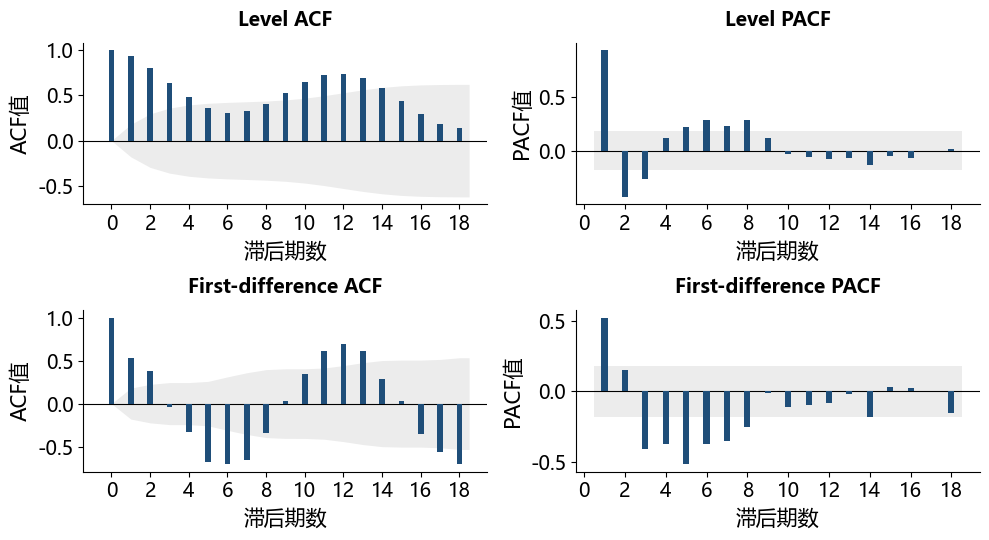

In [12]:
summary_figure, summary_axes = summary_analysis.plot()
print("plot() 返回：", type(summary_figure).__name__, summary_axes.shape)
print("figure_ 是否为同一对象：", summary_analysis.figure_ is summary_figure)
print("axes_ 是否为同一对象：", summary_analysis.axes_ is summary_axes)
plt.show()

In [13]:
# 含缺失值时，统计摘要仍可访问；诊断图不会擅自删行或插值。
missing_summary = TimeSeriesSummary(series_with_gap, nlags=18)
print(
    "missing count =",
    missing_summary.n_missing,
    "; timestamps =",
    missing_summary.missing_timestamps,
)
print(missing_summary.summary(plot=False))

missing count = 2 ; timestamps = (Timestamp('2017-01-01 00:00:00'), Timestamp('2017-02-01 00:00:00'))
Time Series Summary
Name               : sales
Observations       : 120
Valid observations : 118
Frequency          : MS
Start              : 2015-01-01T00:00:00
End                : 2024-12-01T00:00:00
Missing values     : 2
Missing ratio      : 1.67%
Missing timestamps : 2017-01-01T00:00:00, 2017-02-01T00:00:00
--------------------------------------------------
Mean               : 114.744
Standard deviation : 10.1906
Minimum            : 94.4523
First quartile     : 106.827
Median             : 114.698
Third quartile     : 122.259
Maximum            : 134.665


## 5. `eacf()`：非季节 ARMA 阶数识别

### 函数签名

```python
eacf(data, ar_max=7, ma_max=13, *, variable=None)
```

### 参数

| 参数 | 类型与默认值 | 含义 |
|---|---|---|
| `data` | 一维数组、`Series` 或 `DataFrame` | 一条完整、有限、非常数的数值序列。多列 DataFrame 必须指定 `variable`。 |
| `ar_max` | 非负整数，默认 `7` | 表中展示的最大 AR 阶数；行数为 `ar_max + 1`。 |
| `ma_max` | 非负整数，默认 `13` | 表中展示的最大 MA 阶数；列数为 `ma_max + 1`。 |
| `variable` | 列名或 `None` | 多列 DataFrame 中要分析的唯一列。 |

### 返回值：`EACFResult`

| 字段或方法 | 含义 |
|---|---|
| `.values` | 浮点型 EACF 数值矩阵。 |
| `.significant` | 与 `.values` 同形状的显著性布尔矩阵。 |
| `.symbols` | `"x"`/`"o"` 符号矩阵。`x` 表示显著，`o` 表示不显著。 |
| `.ar_orders`、`.ma_orders` | 矩阵行列对应的 AR、MA 阶数。 |
| `.nobs` | 实际使用的观测数。 |
| `.summary()` | 返回传统 `x/o` 文本表；`print(result)` 效果相同。 |

从左上角出现的 `o` 三角形只能用于提出候选 `(p, q)`，不能自动决定唯一模型。所需最小样本量随 `ar_max` 和 `ma_max` 增加；不足时函数会报告明确下限。

In [14]:
eacf_rng = np.random.default_rng(20260802)
innovations = eacf_rng.normal(size=500)
ar2_values = np.zeros(500)
for position in range(2, len(ar2_values)):
    ar2_values[position] = (
        0.65 * ar2_values[position - 1]
        - 0.25 * ar2_values[position - 2]
        + innovations[position]
    )

ar2_series = pd.Series(ar2_values[100:], name="ar2")
eacf_input = pd.DataFrame(
    {
        "ar2": ar2_series,
        "comparison_noise": eacf_rng.normal(size=len(ar2_series)),
    }
)
eacf_result = eacf(
    eacf_input,
    ar_max=5,
    ma_max=5,
    variable="ar2",
)
print("返回类型：", type(eacf_result).__name__)
print("观测数：", eacf_result.nobs)

返回类型： EACFResult
观测数： 400


In [15]:
eacf_numeric_table = pd.DataFrame(
    eacf_result.values,
    index=pd.Index(eacf_result.ar_orders, name="AR order"),
    columns=pd.Index(eacf_result.ma_orders, name="MA order"),
)
eacf_symbol_table = pd.DataFrame(
    eacf_result.symbols,
    index=pd.Index(eacf_result.ar_orders, name="AR order"),
    columns=pd.Index(eacf_result.ma_orders, name="MA order"),
)
eacf_significance_table = pd.DataFrame(
    eacf_result.significant,
    index=eacf_numeric_table.index,
    columns=eacf_numeric_table.columns,
)

print("数值表 result.values：")
display(eacf_numeric_table.round(4))
print("符号表 result.symbols：")
display(eacf_symbol_table)
print("显著性表 result.significant：")
display(eacf_significance_table)

数值表 result.values：


MA order,0,1,2,3,4,5
AR order,,,,,,
0,0.4753,-0.0178,-0.1485,-0.0902,0.0031,0.0562
1,0.4928,-0.0599,-0.1784,-0.0971,0.0057,0.0683
2,0.0517,-0.0428,0.0903,0.0441,-0.0634,0.0768
3,0.4894,0.0077,0.0806,0.0464,-0.0115,0.0759
4,0.3934,-0.1036,0.0355,0.0504,0.0178,0.0798
5,-0.4835,0.4442,-0.3669,0.0429,-0.0463,0.1101


符号表 result.symbols：


MA order,0,1,2,3,4,5
AR order,,,,,,
0,x,o,x,o,o,o
1,x,o,x,o,o,o
2,o,o,o,o,o,o
3,x,o,o,o,o,o
4,x,x,o,o,o,o
5,x,x,x,o,o,x


显著性表 result.significant：


MA order,0,1,2,3,4,5
AR order,,,,,,
0,True,False,True,False,False,False
1,True,False,True,False,False,False
2,False,False,False,False,False,False
3,True,False,False,False,False,False
4,True,True,False,False,False,False
5,True,True,True,False,False,True


In [16]:
print(eacf_result.summary())

Extended Autocorrelation Function
Observations: 400
AR\MA    0    1    2    3    4    5
    0    x    o    x    o    o    o
    1    x    o    x    o    o    o
    2    o    o    o    o    o    o
    3    x    o    o    o    o    o
    4    x    x    o    o    o    o
    5    x    x    x    o    o    x
x = significant
o = not significant


## 6. `STL`：趋势—季节分解

### 构造签名

```python
STL(
    data,
    period,
    *,
    seasonal=7,
    trend=None,
    low_pass=None,
    seasonal_deg=1,
    trend_deg=1,
    low_pass_deg=1,
    robust=False,
    seasonal_jump=1,
    trend_jump=1,
    low_pass_jump=1,
    missing="raise",
)
```

### 构造参数

| 参数 | 类型与默认值 | 含义 |
|---|---|---|
| `data` | 一维数值数据 | 要分解的序列；至少包含两个完整周期。进入结果后为 NumPy 数组。 |
| `period` | 必填，整数 `>= 2` | 一个季节周期包含的观测数；月度年度季节性通常为 `12`，季度为 `4`。 |
| `seasonal` | 奇数，默认 `7` | 季节 LOESS 平滑窗口，通常不小于 7。 |
| `trend` | 奇数或 `None` | 趋势平滑窗口；`None` 时由 `period` 和 `seasonal` 自动确定。 |
| `low_pass` | 奇数或 `None` | 低通滤波窗口；`None` 时取大于 `period` 的最小奇数。 |
| `seasonal_deg` | `0` 或 `1`，默认 `1` | 季节 LOESS 的局部多项式次数：常数或线性。 |
| `trend_deg` | `0` 或 `1`，默认 `1` | 趋势 LOESS 的局部多项式次数。 |
| `low_pass_deg` | `0` 或 `1`，默认 `1` | 低通 LOESS 的局部多项式次数。 |
| `robust` | `bool`，默认 `False` | 是否使用稳健权重降低异常值影响。 |
| `seasonal_jump` | 正整数，默认 `1` | 季节平滑每隔多少点做一次 LOESS，中间线性插值；增大可提速。 |
| `trend_jump` | 正整数，默认 `1` | 趋势平滑的计算步长。 |
| `low_pass_jump` | 正整数，默认 `1` | 低通平滑的计算步长。 |
| `missing` | `"raise"` 或 `"drop"` | `raise` 遇缺失或无穷立即报错；`drop` 删除相应位置并记录在模型的 `.dropped_positions`。删除会改变时间间隔，应谨慎使用。 |

### 拟合方法

```python
result = model.fit(inner_iter=None, outer_iter=None)
```

| 参数 | 含义 |
|---|---|
| `inner_iter` | 内循环次数。`None` 时，稳健模式默认 2，非稳健模式默认 5。 |
| `outer_iter` | 外循环次数。`None` 时，稳健模式默认 15，非稳健模式默认 0。 |

模型对象的 `.summary()` 会在尚未拟合时自动调用 `.fit()`；拟合结果同时保存在 `.result_`。


### `STL` 模型对象

调用构造函数先得到模型对象，而不是分解结果：

| 属性或方法 | 含义 |
|---|---|
| `.data` | 实际进入模型的一维数组。 |
| `.period`、`.config` | 实际周期和完整平滑配置。 |
| `.missing`、`.dropped_positions` | 缺失策略和被删除的原始零基位置。 |
| `.result_` | 拟合前为 `None`；拟合后指向 `STLResult`。 |
| `.fit(inner_iter, outer_iter)` | 执行分解并返回 `STLResult`。 |
| `.summary()` | 必要时自动拟合，并返回结果摘要。 |

### 返回值：`STLResult`

| 字段、属性或方法 | 含义 |
|---|---|
| `.observed` | 进入分解的观测数组。 |
| `.trend` | 趋势分量。 |
| `.seasonal` | 季节分量。 |
| `.residuals` | 残差分量。 |
| `.weights` | 稳健权重，范围 `[0, 1]`。 |
| `.period` | 实际周期。 |
| `.config` | 实际平滑与稳健配置字典。 |
| `.nobs` | 分解使用的观测数。 |
| `.fitted_values` | `trend + seasonal`。 |
| `.summary()` | 返回分解摘要文本。 |
| `.plot(title=None)` | 返回 `(figure, axes)`，绘制观测、趋势、季节和残差。 |

In [17]:
stl_model = STL(
    complete_series,
    period=12,
    seasonal=13,
    trend=None,
    low_pass=None,
    robust=True,
    seasonal_jump=1,
    trend_jump=1,
    low_pass_jump=1,
    missing="raise",
)
stl_result = stl_model.fit(inner_iter=None, outer_iter=None)

print("模型类型：", type(stl_model).__name__)
print("结果类型：", type(stl_result).__name__)
print("result_ 是否为同一对象：", stl_model.result_ is stl_result)
print(stl_result.summary())

模型类型： STL
结果类型： STLResult
result_ 是否为同一对象： True
STL Decomposition Result
Observations       : 120
Period             : 12
Robust             : True
Seasonal smoother  : 13
Trend smoother     : 21
Low-pass smoother  : 13
Residual std. dev. : 0.949574


In [18]:
stl_components = pd.DataFrame(
    {
        "observed": stl_result.observed,
        "trend": stl_result.trend,
        "seasonal": stl_result.seasonal,
        "residuals": stl_result.residuals,
        "fitted_values": stl_result.fitted_values,
        "weights": stl_result.weights,
    },
    index=complete_series.index,
)

stl_properties = pd.Series(
    {
        "nobs": stl_result.nobs,
        "period": stl_result.period,
        "dropped_positions": stl_model.dropped_positions,
        "config": stl_result.config,
    },
    name="STLResult",
)
display(stl_properties)
display(stl_components.head())

nobs                                                               120
period                                                              12
dropped_positions                                                   ()
config               {'period': 12, 'seasonal': 13, 'seasonal_deg':...
Name: STLResult, dtype: object

,observed,trend,seasonal,residuals,fitted_values,weights
2015-01-01,99.200680,98.387387,0.441495,0.371798,98.828882,0.986059
2015-02-01,102.073326,98.787591,3.659583,-0.373848,102.447174,0.985905
2015-03-01,105.842219,99.186072,6.777535,-0.121389,105.963607,0.998509
2015-04-01,106.820540,99.582248,8.099514,-0.861222,107.681762,0.926344
2015-05-01,109.218311,99.975777,7.598023,1.644510,107.573800,0.745023


plot() 返回： Figure (4,)


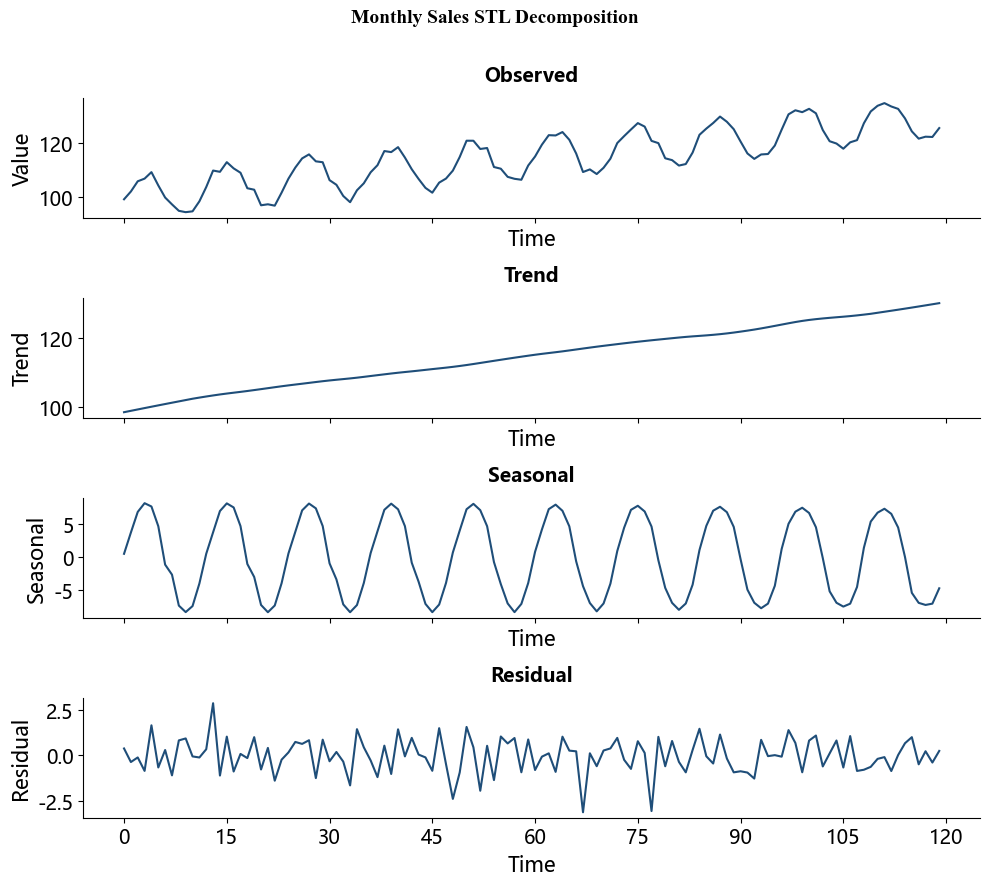

In [19]:
stl_figure, stl_axes = stl_result.plot(
    title="Monthly Sales STL Decomposition"
)
print("plot() 返回：", type(stl_figure).__name__, stl_axes.shape)
plt.show()

### `missing="drop"` 的结果如何查看

删除位置记录在 `STL` 模型对象的 `.dropped_positions`，而不是 `STLResult` 中。对于规则时间序列，删除观测会破坏等间隔语义，通常应先采用有统计依据的插值方法。

In [20]:
stl_missing_data = complete_series.to_numpy(copy=True)
stl_missing_data[12] = np.nan
stl_drop_model = STL(
    stl_missing_data,
    period=12,
    missing="drop",
)
stl_drop_result = stl_drop_model.fit()

print("删除的原始位置：", stl_drop_model.dropped_positions)
print("原始长度：", len(stl_missing_data))
print("分解长度：", stl_drop_result.nobs)

删除的原始位置： (12,)
原始长度： 120
分解长度： 119


## Checks

以下断言不是额外分析，而是验证本教程中的调用、返回类型、主要字段和参数行为与公共 API 契约一致。

In [21]:
# difference
assert isinstance(first_difference, pd.Series)
assert first_difference.index.equals(complete_series.index)
assert first_difference.isna().sum() == 1
assert second_difference.isna().sum() == 2
assert monthly_yoy_log_difference.isna().sum() == 12

# boxcox
assert isinstance(boxcox_fitted, BoxCoxResult)
assert isinstance(boxcox_fitted.data, pd.Series)
assert np.isfinite(boxcox_fitted.lmbda)
assert boxcox_applied.lmbda == boxcox_fitted.lmbda
assert boxcox_transformed.index.equals(complete_series.index)
assert isinstance(boxcox_frame_fitted.lmbda, pd.Series)
pd.testing.assert_series_equal(
    boxcox_frame_applied.lmbda,
    boxcox_frame_fitted.lmbda,
)

# interpolate_missing
assert isinstance(interpolation, InterpolationResult)
assert interpolation.n_missing == 2
assert interpolation.n_filled == 2
assert interpolation.n_remaining == 0
assert interpolation.complete
assert long_gap_result.n_filled == 0
assert edge_result.complete

# TimeSeriesSummary
assert summary_analysis.series.name == "sales"
assert summary_analysis.nobs == len(complete_series)
assert summary_analysis.n_missing == 0
assert summary_analysis.figure_ is summary_figure
assert summary_analysis.axes_ is summary_axes
assert missing_summary.n_missing == 2

# EACF
assert isinstance(eacf_result, EACFResult)
assert eacf_result.values.shape == (6, 6)
assert eacf_result.significant.shape == (6, 6)
assert eacf_result.symbols.shape == (6, 6)
assert eacf_result.nobs == len(ar2_series)

# STL
assert isinstance(stl_result, STLResult)
assert stl_model.result_ is stl_result
assert stl_result.nobs == len(complete_series)
np.testing.assert_allclose(
    stl_result.observed,
    stl_result.trend + stl_result.seasonal + stl_result.residuals,
    rtol=1e-10,
    atol=1e-10,
)
assert stl_drop_model.dropped_positions == (12,)
assert stl_drop_result.nobs == len(stl_missing_data) - 1

print("All TsUtils parameter, return-object, and usage checks passed.")

All TsUtils parameter, return-object, and usage checks passed.


## Next Steps

- 需要转换数据时，先明确统计含义，再选择 `difference()` 或 `boxcox()`；两者不是可互换的标准化手段。
- 需要处理缺失值时，通过 `InterpolationResult` 的掩码和计数审计实际改动，不要只取 `.data` 后忘记检查。
- ACF/PACF、EACF 和 STL 都依赖输入语义与参数选择；频率、周期和缺失处理应由数据生成过程决定。
- 将本 notebook 替换为真实数据时，保留参数、返回对象访问和 Checks 单元，确保流程仍可复现。